## Работа Максимовой Алины 6133-010402D
Импортируем необходимые библиотеки:

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32

Проверим что CUDA подключен:

In [8]:
# Проверка наличия GPU
assert cuda.is_available(), "CUDA GPU не найден"

СPU версия:

In [12]:
def monte_carlo_cpu(N):
    count = 0
    for _ in range(N):
        x, y = np.random.random(), np.random.random()
        if x*x + y*y <= 1.0:
            count += 1
    return 4.0 * count / N

GPU версия:

In [15]:
@cuda.jit
def monte_carlo_gpu_kernel(rng_states, results_counter):
    idx = cuda.grid(1)
    if idx < results_counter.size:
        # Генерируем две случайные координаты на GPU
        x = xoroshiro128p_uniform_float32(rng_states, idx)
        y = xoroshiro128p_uniform_float32(rng_states, idx)
        if x*x + y*y <= 1.0:
            # Атомарно увеличиваем счётчик точек внутри круга
            cuda.atomic.add(results_counter, 0, 1)

def monte_carlo_gpu(N, seed=42):
    # Подготовка состояний генератора случайных чисел
    rng_states = create_xoroshiro128p_states(N, seed=seed)

    # Счётчик точек внутри круга (на GPU)
    counter_gpu = cuda.device_array(1, dtype=np.int32)
    counter_gpu[0] = 0

    # Запуск ядра
    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block
    monte_carlo_gpu_kernel[blocks_per_grid, threads_per_block](rng_states, counter_gpu)

    # Копируем результат с GPU на CPU
    inside_circle = counter_gpu.copy_to_host()[0]
    return 4.0 * inside_circle / N

Функция запуска эксперимента:

In [18]:
def run_experiment(N):
    # CPU
    start_cpu = time.perf_counter()
    pi_cpu = monte_carlo_cpu(N)
    time_cpu = time.perf_counter() - start_cpu

    # GPU
    start_gpu = time.perf_counter()
    pi_gpu = monte_carlo_gpu(N)
    time_gpu = time.perf_counter() - start_gpu

    return pi_cpu, time_cpu, pi_gpu, time_gpu

Разогрев CUDA:

In [22]:
print("Разогрев GPU...")
_ = monte_carlo_gpu(1000)
print("Разогрев завершён.")

Разогрев GPU...
Разогрев завершён.


Эксперимент:

In [34]:
# Диапазон N
Ns = [10**3, 2*10**3, 5*10**3, 10**4, 2*10**4, 5*10**4, 10**5, 2*10**5, 5*10**5, 10**6]

cpu_times = []
gpu_times = []
pi_cpu_vals = []
pi_gpu_vals = []

print("Вычисление π методом Монте-Карло (CPU vs GPU)")
print("="*60)

for N in Ns:
   pi_cpu, time_cpu, pi_gpu, time_gpu = run_experiment(N)
   cpu_times.append(time_cpu)
   gpu_times.append(time_gpu)
   pi_cpu_vals.append(pi_cpu)
   pi_gpu_vals.append(pi_gpu)

# Вычисление ускорения
speedups = [cpu / gpu for cpu, gpu in zip(cpu_times, gpu_times)]

# Таблица результатов
results_df = pd.DataFrame({
    'Число точек (N)': Ns,
    'π (CPU)': pi_cpu_vals,
    'Время CPU (сек)': cpu_times,
    'π (GPU)': pi_gpu_vals,
    'Время GPU (сек)': gpu_times,
    'Ускорение (CPU/GPU)': speedups
})
print("\n" + "="*60)
print("Таблица результатов:")
print(results_df.to_string(index=False))

Вычисление π методом Монте-Карло (CPU vs GPU)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))



Таблица результатов:
 Число точек (N)  π (CPU)  Время CPU (сек)  π (GPU)  Время GPU (сек)  Ускорение (CPU/GPU)
            1000 3.116000         0.001141 0.004000         0.005044             0.226148
            2000 3.122000         0.002244 0.002000         0.001527             1.469338
            5000 3.178400         0.005558 0.000800         0.001984             2.801362
           10000 3.122000         0.011265 0.000400         0.003214             3.505357
           20000 3.159200         0.022391 0.000200         0.005259             4.257434
           50000 3.134400         0.056962 0.000080         0.011214             5.079478
          100000 3.134200         0.112855 0.000040         0.022575             4.999153
          200000 3.139520         0.226850 0.000020         0.043111             5.262021
          500000 3.140608         0.576715 0.000008         0.105205             5.481834
         1000000 3.142924         1.158620 0.000004         0.212554          

Графики:

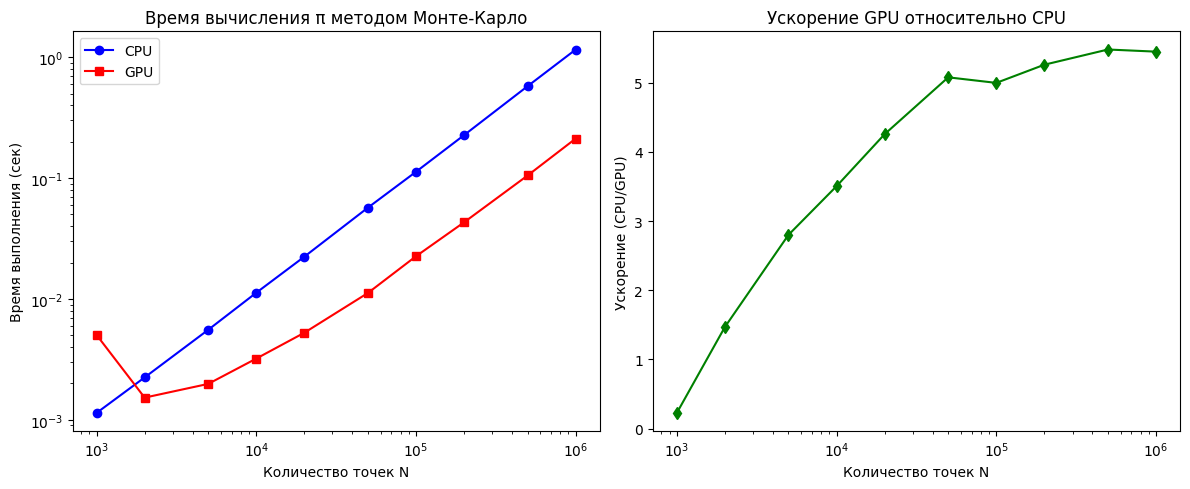

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График времени выполнения
ax1.plot(Ns, cpu_times, 'o-', label='CPU', color='blue')
ax1.plot(Ns, gpu_times, 's-', label='GPU', color='red')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Количество точек N')
ax1.set_ylabel('Время выполнения (сек)')
ax1.set_title('Время вычисления π методом Монте-Карло')
ax1.legend()

# График ускорения
ax2.plot(Ns, speedups, 'd-', color='green')
ax2.set_xscale('log')
ax2.set_xlabel('Количество точек N')
ax2.set_ylabel('Ускорение (CPU/GPU)')
ax2.set_title('Ускорение GPU относительно CPU')
plt.tight_layout()
plt.show()